# Tarefa - Álgebra Linear

A célula abaixo gera dados de notas de duas provas, p1 e p2, conforme em aula, mas com mais alunos.

## 1. Reduzindo correlações

a) Já vimos que expressar os dados através da média e diferença é uma transformação linear. Obtenha a média e a diferença através de uma multiplicação matricial, conforme visto em aula.

b) Calcule a correlação entre os dados da **p1** e **p2**

c) Calcule a correlação entre os dados transformados (média e diferença)

d) Comente as correlações observadas.

In [86]:
# Importa as bibliotecas necessárias para análise de dados, visualização e manipulação numérica
import pandas as pd  # Biblioteca para manipulação de dados em DataFrames
import seaborn as sns  # Biblioteca para visualização de dados (não utilizada diretamente no código atual)
import numpy as np  # Biblioteca para operações numéricas e manipulação de arrays
import matplotlib.pyplot as plt  # Biblioteca para criação de gráficos

# Configura o ambiente para exibir gráficos diretamente no notebook
%matplotlib inline

In [87]:
# Configuração da semente para reprodutibilidade
np.random.seed(123)

# Geração dos dados para as provas p1 e p2
p1 = np.random.random(50) * 10  # Gera 50 valores aleatórios entre 0 e 10
p1[p1 > 10] = 10  # Limita os valores máximos a 10
p1[p1 < 0] = 0  # Limita os valores mínimos a 0

p2 = p1 + np.random.normal(0, 1, 50)  # Adiciona ruído normal aos valores de p1
p2[p2 > 10] = 10  # Limita os valores máximos a 10
p2[p2 < 0] = 0  # Limita os valores mínimos a 0

# Criação do DataFrame com os dados gerados
df = pd.DataFrame({'p1': p1, 'p2': p2})  # Cria um DataFrame com as colunas p1 e p2
df['média'] = df.mean(axis=1)  # Calcula a média das colunas p1 e p2
df['evolução'] = df['média'] - df['p1']  # Calcula a evolução em relação à média

# Função para realizar transformações lineares e plotar os dados
def transf_linear(m, df, t='padrão'):
    """
    Realiza uma transformação linear e plota os dados transformados.

    Parâmetros:
    - m: matriz de transformação linear (numpy.ndarray)
    - df: DataFrame contendo os dados originais
    - t: tipo de transformação ('padrão' ou 'transposta')
    """
    # Configuração do gráfico
    fig = plt.figure(figsize=(18, 8))
    ax = fig.add_subplot(1, 1, 1)
    xmin, xmax, ymin, ymax = -15, 15, -15, 15  # Define os limites do gráfico
    ax.set(xlim=(xmin, xmax), ylim=(ymin, ymax))
    ax.set_aspect("equal", "box")  # Define a proporção do gráfico
    ax.set_xticks(range(xmin, xmax + 1))  # Define os ticks do eixo x
    ax.set_yticks(range(ymin, ymax + 1))  # Define os ticks do eixo y
    ax.axvline(0, linewidth=0.5, color='black', linestyle='--')  # Linha vertical no eixo y=0
    ax.axhline(0, linewidth=0.5, color='black', linestyle='--')  # Linha horizontal no eixo x=0

    # Desenha as setas representando as colunas da matriz de transformação
    if t == 'padrão':
        ax.arrow(0, 0, m[0, 0], m[1, 0], head_width=0.5, head_length=0.1, fc="blue", ec="blue", length_includes_head=True)
        ax.arrow(0, 0, m[1, 0], m[1, 1], head_width=0.5, head_length=0.1, fc="red", ec="red", length_includes_head=True)
    elif t == 'transposta':
        ax.arrow(0, 0, m[0, 0], m[0, 1], head_width=0.5, head_length=0.1, fc="blue", ec="blue", length_includes_head=True)
        ax.arrow(0, 0, m[1, 0], m[1, 1], head_width=0.5, head_length=0.1, fc="red", ec="red", length_includes_head=True)

    # Plota os dados originais e transformados
    ax.scatter(df['p1'], df['p2'], color='red', alpha=0.5, label='Originais')  # Dados originais
    ax.scatter(df['média'], df['evolução'], color='blue', alpha=0.5, label='Transformados')  # Dados transformados

    # Adiciona a legenda
    plt.legend()

# Matrizes de transformação linear
matriz_de_transformacao = np.array([
    [0.5, 0.5],  # Calcula a média (peso igual para p1 e p2)
    [-1, 1],     # Calcula a diferença (subtração de p1 de p2)
])

matriz_de_soma_e_diferenca = np.array([
    [1, 1],  # Soma p1 e p2
    [1, -1],  # Diferença entre p1 e p2
])


Text(0.5, 1.0, 'Transformação Linear')

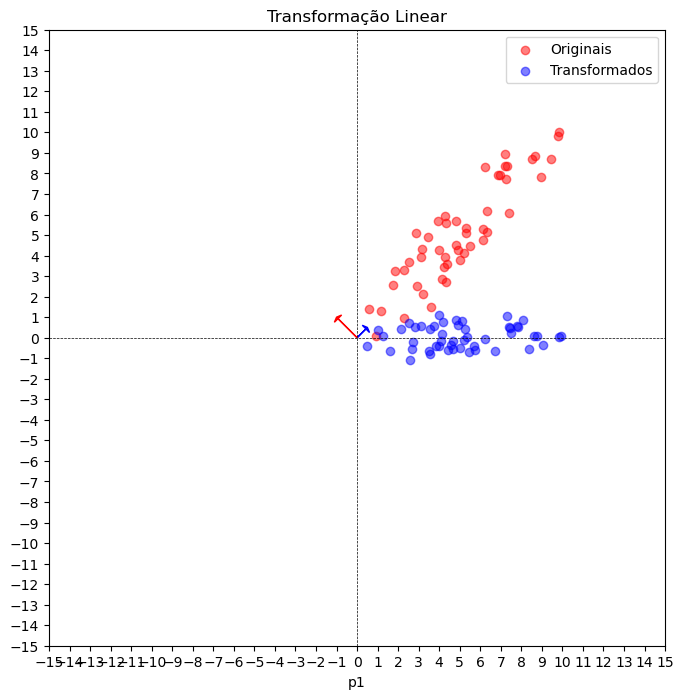

In [88]:
# Aplica a transformação linear utilizando a matriz de transformação especificada (matriz_de_transformacao)
# e os dados do DataFrame (df). O parâmetro 't' indica que a transformação será feita com a matriz transposta.
transf_linear(matriz_de_transformacao, df=df, t='transposta')  

# Define o rótulo do eixo x no gráfico como "p1"
plt.xlabel("p1")

# Define o título do gráfico como "Transformação Linear"
plt.title("Transformação Linear")

In [89]:
# Lista para armazenar as correlações calculadas
lista_de_correlacoes = [
    df[['p1', 'p2']].corr().iloc[0, 1],  # Calcula a correlação entre as colunas p1 e p2 do DataFrame
    df[['média', 'evolução']].corr().iloc[0, 1],  # Calcula a correlação entre as colunas média e evolução do DataFrame
]

# Exibe a correlação entre p1 e p2, arredondada para 3 casas decimais
print(f"Correlação entre p1 e p2:", round(lista_de_correlacoes[0], 3))

# Exibe a correlação entre média e evolução, arredondada para 3 casas decimais
print(f"Correlação entre média e evolução:", round(lista_de_correlacoes[1], 3))

Correlação entre p1 e p2: 0.896
Correlação entre média e evolução: 0.133


A baixa correlação dos valores absolutos de "média" e "evolução" se deve por serem de duas naturezas distintas, onde "evolução" visa demonstrar a diferença de valores, sendo favorável aos extremos, enquanto a média suaviza a diferença entre as provas, a evolução evidencia essa diferença, o que naturalmente reduz a correlação entre elas..

## 2. Soma e diferença

Realize agora uma transformação semelhante, mas que ao invés da média, dê a soma da **p1** e **p2**. Construa o gráfico e conclua que diferenças visuais você observa.

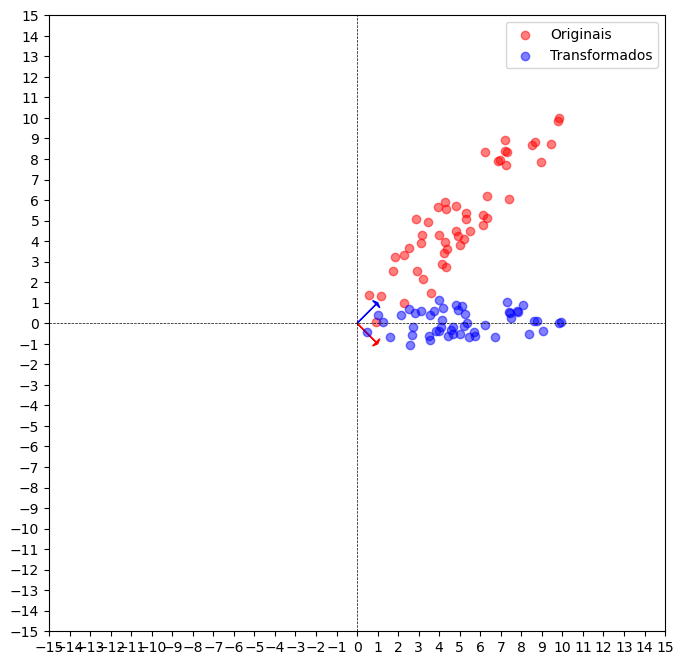

In [90]:
transf_linear(matriz_de_soma_e_diferenca, df=df, t='transposta')  # Chama a função de transformação linear

In [91]:
# Adiciona uma nova coluna 'soma' ao DataFrame 'df', calculando a soma das colunas 'p1' e 'p2' para cada linha
df['soma'] = df[['p1', 'p2']].sum(axis=1)

# Atualiza a lista de correlações com os seguintes valores:
# 1. Correlação entre as colunas 'p1' e 'p2' do DataFrame
# 2. Correlação entre as colunas 'soma' e 'evolução' do DataFrame
lista_de_correlacoes = [
    df[['p1', 'p2']].corr().iloc[0, 1],  # Correlação entre 'p1' e 'p2'
    df[['soma', 'evolução']].corr().iloc[0, 1],  # Correlação entre 'soma' e 'evolução'
]

# Exibe a correlação entre 'p1' e 'p2', arredondada para 3 casas decimais
print(f"Correlação entre p1 e p2:", round(lista_de_correlacoes[0], 3))

# Exibe a correlação entre 'soma' e 'evolução', arredondada para 3 casas decimais
print(f"Correlação entre soma e evolução:", round(lista_de_correlacoes[1], 3))

Correlação entre p1 e p2: 0.896
Correlação entre soma e evolução: 0.133
